In [1]:
# =============================================================================
# NIH CXR UNet Reconstruction Experiment
# =============================================================================
# Replicates OASIS UNet pipeline for NIH ChestX-ray14 ReID split.
#
# Two experiments:
#   gs0  — minimal masking (lower bound of GS effect)
#   gs50 — maximum masking (upper bound of GS effect)
#
# Evaluation:
#   1. Intensity  — SSIM, PSNR, MAE, FFT spectral fidelity
#   2. Functionality — ReID accuracy on reconstructed images
#                      using raw-trained models (all 4 combos)
# =============================================================================

import os
import gc
import json
import time
import random
import warnings
from pathlib import Path
from typing import Dict, List, Tuple, Optional

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import models

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
warnings.filterwarnings('ignore')

# ── Metrics ──────────────────────────────────────────────────────────────────
# ── Metrics — pure PyTorch, no external library (matches OASIS) ───────────────

def _gaussian_window(
    window_size : int   = 11,
    sigma       : float = 1.5,
    channels    : int   = 1,
    device      : str   = 'cpu',
) -> torch.Tensor:
    coords = torch.arange(window_size, device=device).float() \
             - window_size // 2
    g = torch.exp(-(coords ** 2) / (2 * sigma ** 2))
    g = g / g.sum()
    w = (g[:, None] * g[None, :]).unsqueeze(0).unsqueeze(0)
    return w.repeat(channels, 1, 1, 1)


def ssim_torch(
    x           : torch.Tensor,
    y           : torch.Tensor,
    window_size : int   = 11,
    sigma       : float = 1.5,
    data_range  : float = 1.0,
    eps         : float = 1e-6,
) -> torch.Tensor:
    """SSIM — returns per-image scores (N,)."""
    x, y = x.float(), y.float()
    C1   = (0.01 * data_range) ** 2
    C2   = (0.03 * data_range) ** 2
    ch   = x.shape[1]
    w    = _gaussian_window(window_size, sigma, ch, device=x.device)

    pad  = window_size // 2
    mu_x = F.conv2d(x,   w, padding=pad, groups=ch)
    mu_y = F.conv2d(y,   w, padding=pad, groups=ch)

    sigma_x2 = F.conv2d(x * x, w, padding=pad, groups=ch) - mu_x ** 2
    sigma_y2 = F.conv2d(y * y, w, padding=pad, groups=ch) - mu_y ** 2
    sigma_xy = F.conv2d(x * y, w, padding=pad, groups=ch) - mu_x * mu_y

    num = (2 * mu_x * mu_y + C1) * (2 * sigma_xy + C2)
    den = (mu_x ** 2 + mu_y ** 2 + C1) * (sigma_x2 + sigma_y2 + C2)

    return (num / torch.clamp(den, min=eps)).mean(dim=(1, 2, 3))


def psnr_torch(
    x          : torch.Tensor,
    y          : torch.Tensor,
    data_range : float = 1.0,
    eps        : float = 1e-8,
) -> torch.Tensor:
    """PSNR — returns per-image scores (N,) in dB."""
    mse = F.mse_loss(x, y, reduction='none').mean(dim=(1, 2, 3))
    return 10.0 * torch.log10((data_range ** 2) / (mse + eps))


print("✓ SSIM and PSNR implemented (pure PyTorch, no external library)")

# =============================================================================
# PATHS
# =============================================================================
PROJECT_ROOT  = Path('.')
REID_NPZ_DIR  = PROJECT_ROOT / 'data'    / 'chest' / 'reid_npz'
REID_META_DIR = PROJECT_ROOT / 'data'    / 'metadata' / 'reid'
MODELS_DIR    = PROJECT_ROOT / 'models'  / 'nih_cxr' / 'reid'
RESULTS_DIR   = PROJECT_ROOT / 'results' / 'nih_cxr' / 'unet'
UNET_DIR      = PROJECT_ROOT / 'models'  / 'nih_cxr' / 'unet'
FIG_DIR       = RESULTS_DIR  / 'figures'

for d in [RESULTS_DIR, UNET_DIR, FIG_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# =============================================================================
# CONFIG
# =============================================================================
SEED        = 1337
IMG_SIZE    = 224
DEVICE      = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# GS conditions — lower and upper bound only
GS_LEVELS   = [0.0, 0.5]   # p=0.0 → gs0, p=0.5 → gs50
P_TO_TAG    = {0.0: 'gs0', 0.5: 'gs50'}
TAG_TO_P    = {'gs0': 0.0, 'gs50': 0.5}

# UNet hyperparameters — match OASIS
UNET_EPOCHS      = 50
UNET_LR          = 2e-4
UNET_WD          = 1e-4
UNET_BATCH       = 16
UNET_PATIENCE    = 5
W_L1             = 1.0
W_SSIM           = 0.1

# ReID evaluation
REID_BATCH       = 32
NUM_CLASSES      = 1739   # unique patients

ARCHITECTURES    = ['resnet18', 'densenet121']
INITIALIZATIONS  = ['Pretrained', 'Scratch']

def set_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False

set_seed(SEED)

if torch.cuda.is_available():
    print(f"GPU  : {torch.cuda.get_device_name(0)}")
    print(f"VRAM : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")

print(f"\nDevice     : {DEVICE}")
print(f"GS levels  : {GS_LEVELS}")
print(f"UNet dir   : {UNET_DIR}")
print(f"Results dir: {RESULTS_DIR}")

✓ SSIM and PSNR implemented (pure PyTorch, no external library)
GPU  : NVIDIA L4
VRAM : 23.6 GB

Device     : cuda
GS levels  : [0.0, 0.5]
UNet dir   : models/nih_cxr/unet
Results dir: results/nih_cxr/unet


In [2]:
# =============================================================================
# DATA LOADING — from pre-built ReID NPZs
# =============================================================================

def load_reid_npz(
    split     : str,
    condition : str,
) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    Load ReID NPZ for a given split and condition.

    Returns:
        images      : (N, 224, 224) float32
        labels      : (N,) int64    patient label 0–1738
        patient_ids : (N,) int64    original patient ID
    """
    path = REID_NPZ_DIR / f'reid_{split}_{condition}.npz'
    if not path.exists():
        raise FileNotFoundError(f"NPZ not found: {path}")
    data        = np.load(path)
    images      = data['images'].astype(np.float32)
    labels      = data['labels'].astype(np.int64)
    patient_ids = data['patient_ids'].astype(np.int64)
    data.close()
    return images, labels, patient_ids


# ── Load raw splits ───────────────────────────────────────────────────────────
print("=== LOADING RAW SPLITS ===\n")
train_raw, train_labels, train_pids = load_reid_npz('train', 'raw')
val_raw,   val_labels,   val_pids   = load_reid_npz('val',   'raw')
test_raw,  test_labels,  test_pids  = load_reid_npz('test',  'raw')

print(f"  Train raw : {train_raw.shape}  "
      f"patients={len(np.unique(train_pids)):,}  "
      f"range=[{train_raw.min():.3f},{train_raw.max():.3f}]")
print(f"  Val raw   : {val_raw.shape}  "
      f"patients={len(np.unique(val_pids)):,}")
print(f"  Test raw  : {test_raw.shape}  "
      f"patients={len(np.unique(test_pids)):,}")

# ── Load GS variants ──────────────────────────────────────────────────────────
print("\n=== LOADING GS VARIANTS ===\n")
gs_data = {}   # {p: {'train': imgs, 'val': imgs, 'test': imgs}}

for p in GS_LEVELS:
    tag = P_TO_TAG[p]
    gs_data[p] = {}
    for split, raw in [('train', train_raw),
                        ('val',   val_raw),
                        ('test',  test_raw)]:
        imgs, _, _ = load_reid_npz(split, tag)
        gs_data[p][split] = imgs
        print(f"  p={p}  {split:<6} : {imgs.shape}  "
              f"range=[{imgs.min():.3f},{imgs.max():.3f}]")

# ── Load pid_to_label mapping ─────────────────────────────────────────────────
with open(REID_META_DIR / 'pid_to_label.json') as f:
    pid_to_label = {int(k): v for k, v in json.load(f).items()}
print(f"\n  NUM_CLASSES : {len(pid_to_label):,} unique patients")

# ── Verify test labels match pid_to_label ─────────────────────────────────────
for i in range(min(5, len(test_pids))):
    expected = pid_to_label[int(test_pids[i])]
    assert test_labels[i] == expected, \
        f"Label mismatch at {i}: pid={test_pids[i]}"
print("  ✓ Test label alignment verified")

print("\n✓ Data loading complete")

=== LOADING RAW SPLITS ===

  Train raw : (5217, 224, 224)  patients=1,739  range=[0.000,1.000]
  Val raw   : (1739, 224, 224)  patients=1,739
  Test raw  : (3082, 224, 224)  patients=1,739

=== LOADING GS VARIANTS ===

  p=0.0  train  : (5217, 224, 224)  range=[0.000,3.465]
  p=0.0  val    : (1739, 224, 224)  range=[0.000,3.023]
  p=0.0  test   : (3082, 224, 224)  range=[0.000,3.391]
  p=0.5  train  : (5217, 224, 224)  range=[0.000,2.988]
  p=0.5  val    : (1739, 224, 224)  range=[0.000,2.874]
  p=0.5  test   : (3082, 224, 224)  range=[0.000,2.876]

  NUM_CLASSES : 1,739 unique patients
  ✓ Test label alignment verified

✓ Data loading complete


In [3]:
# =============================================================================
# UNET ARCHITECTURE — identical to OASIS
# =============================================================================

class ConvBlock(nn.Module):
    def __init__(self, in_ch: int, out_ch: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1),
            nn.GroupNorm(8, out_ch),
            nn.SiLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1),
            nn.GroupNorm(8, out_ch),
            nn.SiLU(inplace=True),
        )

    def forward(self, x):
        return self.net(x)


class UNet2D(nn.Module):
    def __init__(self, in_ch: int = 1, out_ch: int = 1, base: int = 32):
        super().__init__()
        self.enc1 = ConvBlock(in_ch,       base)
        self.enc2 = ConvBlock(base,        base * 2)
        self.enc3 = ConvBlock(base * 2,    base * 4)
        self.mid  = ConvBlock(base * 4,    base * 8)

        self.up3  = nn.ConvTranspose2d(base * 8, base * 4, 2, stride=2)
        self.dec3 = ConvBlock(base * 8,    base * 4)

        self.up2  = nn.ConvTranspose2d(base * 4, base * 2, 2, stride=2)
        self.dec2 = ConvBlock(base * 4,    base * 2)

        self.up1  = nn.ConvTranspose2d(base * 2, base,     2, stride=2)
        self.dec1 = ConvBlock(base * 2,    base)

        self.out  = nn.Sequential(
            nn.Conv2d(base, out_ch, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(F.max_pool2d(e1, 2))
        e3 = self.enc3(F.max_pool2d(e2, 2))
        m  = self.mid(F.max_pool2d(e3, 2))

        d3 = self.dec3(torch.cat([self.up3(m),  e3], dim=1))
        d2 = self.dec2(torch.cat([self.up2(d3), e2], dim=1))
        d1 = self.dec1(torch.cat([self.up1(d2), e1], dim=1))

        return self.out(d1)


# =============================================================================
# PAIRED INVERSION DATASET
# =============================================================================

class PairedInversionDataset(Dataset):
    """
    Dataset for UNet inversion training.
    Input  (x): GS-transformed image  → (1, H, W)
    Target (y): raw image             → (1, H, W)
    """
    def __init__(
        self,
        x_gs  : np.ndarray,   # (N, H, W) float32
        x_raw : np.ndarray,   # (N, H, W) float32
    ):
        assert len(x_gs) == len(x_raw), \
            f"Length mismatch: {len(x_gs)} vs {len(x_raw)}"
        # Add channel dim → (N, 1, H, W)
        self.x = torch.from_numpy(x_gs).unsqueeze(1).float()
        self.y = torch.from_numpy(x_raw).unsqueeze(1).float()

    def __len__(self):
        return len(self.x)

    def __getitem__(self, idx):
        return self.x[idx], self.y[idx]


# =============================================================================
# LOSS FUNCTION — match OASIS
# =============================================================================

def inversion_loss(
    x_hat  : torch.Tensor,
    x_true : torch.Tensor,
    w_l1   : float = W_L1,
    w_ssim : float = W_SSIM,
) -> Tuple[torch.Tensor, Dict]:
    l1       = F.l1_loss(x_hat, x_true)
    ssim_val = ssim_torch(x_hat, x_true, data_range=1.0)
    if isinstance(ssim_val, torch.Tensor) and ssim_val.dim() > 0:
        ssim_val = ssim_val.mean()
    loss = w_l1 * l1 + w_ssim * (1.0 - ssim_val)
    return loss, {'l1': l1.item(), 'ssim': float(ssim_val)}


# ── Smoke test ────────────────────────────────────────────────────────────────
print("=== UNET SMOKE TEST ===")
_model = UNet2D(in_ch=1, out_ch=1, base=32).to(DEVICE)
_x     = torch.zeros(2, 1, IMG_SIZE, IMG_SIZE).to(DEVICE)
with torch.no_grad():
    _out = _model(_x)
n_params = sum(p.numel() for p in _model.parameters())
print(f"  Input  : {list(_x.shape)}")
print(f"  Output : {list(_out.shape)}  "
      f"range=[{_out.min():.3f},{_out.max():.3f}]")
print(f"  Params : {n_params/1e6:.2f}M")
del _model, _x, _out
torch.cuda.empty_cache()
print("✓ UNet architecture ready")

=== UNET SMOKE TEST ===
  Input  : [2, 1, 224, 224]
  Output : [2, 1, 224, 224]  range=[0.280,0.677]
  Params : 1.93M
✓ UNet architecture ready


In [4]:
# =============================================================================
# UNET TRAINING
# =============================================================================

@torch.no_grad()
def predict_in_batches(
    model      : nn.Module,
    x          : torch.Tensor,   # (N, 1, H, W)
    batch_size : int = 32,
) -> torch.Tensor:
    model.eval()
    preds = []
    for i in range(0, x.shape[0], batch_size):
        xb = x[i:i + batch_size].to(DEVICE)
        preds.append(model(xb).detach().cpu())
        del xb
    return torch.cat(preds, dim=0)


def unet_ckpt_path(p: float) -> Path:
    tag = P_TO_TAG[p]
    d   = UNET_DIR / tag
    d.mkdir(parents=True, exist_ok=True)
    return d / 'best.pt'


def load_trained_unet(p: float) -> UNet2D:
    path = unet_ckpt_path(p)
    if not path.exists():
        raise FileNotFoundError(f"UNet checkpoint not found: {path}")
    payload = torch.load(path, map_location='cpu', weights_only=False)
    model   = UNet2D(in_ch=1, out_ch=1, base=32)
    key     = 'model_state_dict' if 'model_state_dict' in payload \
              else 'model'
    model.load_state_dict(payload[key])
    model.eval()
    return model


def train_unet(p: float) -> Path:
    """
    Train one UNet for a given GS masking level p.
    Input: GS images → Target: raw images
    Uses ReID train/val splits.
    """
    tag      = P_TO_TAG[p]
    ckpt     = unet_ckpt_path(p)
    hist_path = ckpt.parent / 'history.json'

    if ckpt.exists():
        print(f"\n  ✓ UNet {tag} checkpoint exists → skip training")
        return ckpt

    print(f"\n{'='*70}")
    print(f"[TRAIN] UNet for {tag} (p={p})")
    print(f"{'='*70}")

    # DataLoaders
    ds_tr = PairedInversionDataset(gs_data[p]['train'], train_raw)
    ds_va = PairedInversionDataset(gs_data[p]['val'],   val_raw)

    dl_tr = DataLoader(
        ds_tr, batch_size=UNET_BATCH, shuffle=True,
        num_workers=4, pin_memory=True
    )
    dl_va = DataLoader(
        ds_va, batch_size=UNET_BATCH, shuffle=False,
        num_workers=4, pin_memory=True
    )

    print(f"  Train pairs : {len(ds_tr):,}")
    print(f"  Val pairs   : {len(ds_va):,}")

    model     = UNet2D(in_ch=1, out_ch=1, base=32).to(DEVICE)
    optimizer = torch.optim.AdamW(
        model.parameters(), lr=UNET_LR, weight_decay=UNET_WD
    )
    scaler    = torch.amp.GradScaler('cuda', enabled=(DEVICE.type=='cuda'))
    AMP       = (DEVICE.type == 'cuda')

    best_val_loss  = float('inf')
    patience_ctr   = 0
    history        = []

    for epoch in range(1, UNET_EPOCHS + 1):
        t0 = time.time()

        # ── Train ─────────────────────────────────────────────────────────────
        model.train()
        tr_losses = []
        for xg, xr in dl_tr:
            xg = xg.to(DEVICE)
            xr = xr.to(DEVICE)
            optimizer.zero_grad(set_to_none=True)
            with torch.amp.autocast('cuda', enabled=AMP):
                x_hat        = model(xg)
                loss, _      = inversion_loss(x_hat, xr)
            if not torch.isfinite(loss):
                continue
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(optimizer)
            scaler.update()
            tr_losses.append(loss.item())

        # ── Validate ──────────────────────────────────────────────────────────
        model.eval()
        va_losses = []
        with torch.no_grad():
            for xg, xr in dl_va:
                xg = xg.to(DEVICE)
                xr = xr.to(DEVICE)
                with torch.amp.autocast('cuda', enabled=AMP):
                    x_hat   = model(xg)
                    v_loss, _ = inversion_loss(x_hat, xr)
                if torch.isfinite(v_loss):
                    va_losses.append(v_loss.item())

        avg_tr = float(np.mean(tr_losses)) if tr_losses else 0.0
        avg_va = float(np.mean(va_losses)) if va_losses else 0.0
        dt     = time.time() - t0

        # ── Checkpoint & early stop ───────────────────────────────────────────
        if avg_va < best_val_loss - 1e-5:
            best_val_loss = avg_va
            patience_ctr  = 0
            torch.save(
                {
                    'model_state_dict': model.state_dict(),
                    'p'               : p,
                    'tag'             : tag,
                    'epoch'           : epoch,
                    'val_loss'        : avg_va,
                },
                ckpt
            )
            status = '⭐ NEW BEST'
        else:
            patience_ctr += 1
            status = ''

        history.append({'epoch': epoch, 'train': avg_tr, 'val': avg_va})
        print(f"  [E{epoch:03d}] Tr={avg_tr:.4f} | "
              f"Va={avg_va:.4f} | {status} ({dt:.1f}s)")

        if patience_ctr >= UNET_PATIENCE:
            print(f"  [STOP] Early stopping at epoch {epoch}")
            break

    with open(hist_path, 'w') as f:
        json.dump(history, f, indent=2)

    del model, optimizer, scaler
    torch.cuda.empty_cache()
    gc.collect()

    print(f"  ✓ Saved: {ckpt}")
    return ckpt


# ── Train both UNets ──────────────────────────────────────────────────────────
print("=" * 70)
print("UNET TRAINING")
print("=" * 70)

trained_ckpts = {}
for p in GS_LEVELS:
    trained_ckpts[p] = train_unet(p)

print(f"\n✓ All UNets trained:")
for p, ckpt in trained_ckpts.items():
    size_mb = ckpt.stat().st_size / 1e6
    print(f"  p={p} → {ckpt}  ({size_mb:.1f} MB)")

UNET TRAINING

[TRAIN] UNet for gs0 (p=0.0)
  Train pairs : 5,217
  Val pairs   : 1,739
  [E001] Tr=0.0150 | Va=0.0055 | ⭐ NEW BEST (50.4s)
  [E002] Tr=-0.0035 | Va=-0.0008 | ⭐ NEW BEST (48.6s)
  [E003] Tr=-0.0090 | Va=-0.0039 | ⭐ NEW BEST (48.9s)
  [E004] Tr=-0.0109 | Va=-0.0006 |  (48.7s)
  [E005] Tr=-0.0137 | Va=-0.0089 | ⭐ NEW BEST (48.8s)
  [E006] Tr=-0.0147 | Va=-0.0080 |  (48.7s)
  [E007] Tr=-0.0136 | Va=-0.0068 |  (48.7s)
  [E008] Tr=-0.0152 | Va=-0.0178 | ⭐ NEW BEST (48.7s)
  [E009] Tr=-0.0159 | Va=-0.0101 |  (48.7s)
  [E010] Tr=-0.0170 | Va=-0.0090 |  (48.7s)
  [E011] Tr=-0.0173 | Va=-0.0154 |  (48.7s)
  [E012] Tr=-0.0173 | Va=-0.0106 |  (48.6s)
  [E013] Tr=-0.0187 | Va=-0.0177 |  (48.6s)
  [STOP] Early stopping at epoch 13
  ✓ Saved: models/nih_cxr/unet/gs0/best.pt

[TRAIN] UNet for gs50 (p=0.5)
  Train pairs : 5,217
  Val pairs   : 1,739
  [E001] Tr=0.0709 | Va=0.0513 | ⭐ NEW BEST (48.9s)
  [E002] Tr=0.0483 | Va=0.0485 | ⭐ NEW BEST (48.8s)
  [E003] Tr=0.0424 | Va=0.0455 | ⭐

In [6]:
# =============================================================================
# INTENSITY EVALUATION
# =============================================================================

def fft_logmag_l2(
    x   : torch.Tensor,
    y   : torch.Tensor,
    eps : float = 1e-8,
) -> torch.Tensor:
    """Spectral fidelity: log-magnitude L2 in Fourier domain."""
    X  = torch.fft.rfft2(x.float(), norm='ortho')
    Y  = torch.fft.rfft2(y.float(), norm='ortho')
    Xm = torch.log1p(torch.abs(X) + eps)
    Ym = torch.log1p(torch.abs(Y) + eps)
    return (Xm - Ym).pow(2).mean(dim=(1, 2, 3)).sqrt().cpu()


print("=" * 70)
print("INTENSITY EVALUATION")
print("=" * 70)

intensity_results = []

for p in GS_LEVELS:
    tag = P_TO_TAG[p]
    print(f"\n── {tag} (p={p}) ───────────────────────────────────")

    try:
        model = load_trained_unet(p).to(DEVICE)
    except FileNotFoundError as e:
        print(f"  ✗ {e}")
        continue

    # Test inputs and targets
    gs_test_np  = gs_data[p]['test']                      # (N, H, W)
    raw_test_np = test_raw                                 # (N, H, W)

    gs_test_t   = torch.from_numpy(gs_test_np).unsqueeze(1).float()
    raw_test_t  = torch.from_numpy(raw_test_np).unsqueeze(1).float()

    # Reconstruct
    recon_t = predict_in_batches(model, gs_test_t, batch_size=32)

    # Metrics
    ssim_vals = ssim_torch(recon_t, raw_test_t, data_range=1.0)  # (N,)
    psnr_vals = psnr_torch(recon_t, raw_test_t, data_range=1.0)  # (N,)
    mae_vals  = (recon_t - raw_test_t).abs().mean(dim=(1,2,3))   # (N,)
    fft_vals  = fft_logmag_l2(recon_t, raw_test_t)               # (N,)

    ssim_val = float(ssim_vals.mean())
    psnr_val = float(psnr_vals.mean())
    mae_val  = float(mae_vals.mean())
    fft_val  = float(fft_vals.mean())

    # GS vs raw reference (no reconstruction)
    ssim_gs_vals = ssim_torch(gs_test_t, raw_test_t, data_range=1.0)
    psnr_gs_vals = psnr_torch(gs_test_t, raw_test_t, data_range=1.0)
    ssim_gs = float(ssim_gs_vals.mean())
    psnr_gs = float(psnr_gs_vals.mean())
    mae_gs  = float((gs_test_t - raw_test_t).abs().mean())

    print(f"  GS vs Raw      : "
          f"SSIM={float(ssim_gs):.4f}  "
          f"PSNR={float(psnr_gs):.2f}dB  "
          f"MAE={mae_gs:.6f}")
    print(f"  Recon vs Raw   : "
          f"SSIM={ssim_val:.4f}  "
          f"PSNR={psnr_val:.2f}dB  "
          f"MAE={mae_val:.6f}  "
          f"FFT={fft_val:.4f}")
    print(f"  SSIM improvement: {ssim_val - float(ssim_gs):+.4f}")

    intensity_results.append({
        'gs_level'         : tag,
        'p'                : p,
        'n_samples'        : len(raw_test_np),
        # GS vs raw (no reconstruction)
        'gs_ssim'          : float(ssim_gs),
        'gs_psnr'          : float(psnr_gs),
        'gs_mae'           : mae_gs,
        # Reconstruction vs raw
        'recon_ssim'       : ssim_val,
        'recon_psnr'       : psnr_val,
        'recon_mae'        : mae_val,
        'recon_fft'        : fft_val,
        # Improvement
        'ssim_improvement' : ssim_val - float(ssim_gs),
        'psnr_improvement' : psnr_val - float(psnr_gs),
    })

    # Save reconstruction tensors for functionality test
    recon_save = RESULTS_DIR / f'recon_{tag}_test.pt'
    torch.save(recon_t.cpu(), recon_save)
    print(f"  💾 Saved reconstructions: {recon_save.name}")

    del model, recon_t, gs_test_t, raw_test_t
    torch.cuda.empty_cache()
    gc.collect()

# Save intensity results
df_intensity = pd.DataFrame(intensity_results)
df_intensity.to_csv(RESULTS_DIR / 'intensity_results.csv', index=False)

print(f"\n{'='*70}")
print("INTENSITY EVALUATION SUMMARY")
print('='*70)
print(df_intensity[[
    'gs_level', 'n_samples',
    'gs_ssim', 'gs_psnr', 'gs_mae',
    'recon_ssim', 'recon_psnr', 'recon_mae',
    'ssim_improvement', 'psnr_improvement'
]].to_string(index=False))

INTENSITY EVALUATION

── gs0 (p=0.0) ───────────────────────────────────
  GS vs Raw      : SSIM=0.4425  PSNR=6.87dB  MAE=0.419969
  Recon vs Raw   : SSIM=0.9189  PSNR=30.46dB  MAE=0.032156  FFT=0.0117
  SSIM improvement: +0.4764
  💾 Saved reconstructions: recon_gs0_test.pt

── gs50 (p=0.5) ───────────────────────────────────
  GS vs Raw      : SSIM=0.0361  PSNR=8.65dB  MAE=0.294500
  Recon vs Raw   : SSIM=0.7369  PSNR=22.30dB  MAE=0.062838  FFT=0.0322
  SSIM improvement: +0.7008
  💾 Saved reconstructions: recon_gs50_test.pt

INTENSITY EVALUATION SUMMARY
gs_level  n_samples  gs_ssim  gs_psnr   gs_mae  recon_ssim  recon_psnr  recon_mae  ssim_improvement  psnr_improvement
     gs0       3082 0.442454 6.869599 0.419969    0.918862   30.463293   0.032156          0.476408         23.593694
    gs50       3082 0.036113 8.648569 0.294500    0.736922   22.301674   0.062838          0.700809         13.653105


In [11]:
def load_reid_model(arch: str, init: str) -> nn.Module:
    fname = f'{arch}_{init}_raw_best.pth'
    path  = MODELS_DIR / arch / fname
    if not path.exists():
        raise FileNotFoundError(f"ReID model not found: {path}")

    ckpt = torch.load(path, map_location=DEVICE, weights_only=False)
    sd   = ckpt.get('state_dict', ckpt)

    # Detect head structure from checkpoint keys
    # Sequential head: fc.1.weight / classifier.1.weight
    # Plain head     : fc.weight   / classifier.weight
    if arch == 'resnet18':
        has_sequential = 'fc.1.weight' in sd
        model           = models.resnet18(weights=None)
        model.conv1     = nn.Conv2d(
            1, 64, kernel_size=7, stride=2, padding=3, bias=False
        )
        if has_sequential:
            model.fc = nn.Sequential(
                nn.Dropout(p=0.0),
                nn.Linear(512, NUM_CLASSES)
            )
        else:
            model.fc = nn.Linear(512, NUM_CLASSES)

    else:  # densenet121
        has_sequential  = 'classifier.1.weight' in sd
        model           = models.densenet121(weights=None)
        model.features[0] = nn.Conv2d(
            1, 64, kernel_size=7, stride=2, padding=3, bias=False
        )
        if has_sequential:
            model.classifier = nn.Sequential(
                nn.Dropout(p=0.0),
                nn.Linear(1024, NUM_CLASSES)
            )
        else:
            model.classifier = nn.Linear(1024, NUM_CLASSES)

    model.load_state_dict(
        {k.replace('module.', ''): v for k, v in sd.items()}
    )
    model = model.to(DEVICE)
    model.eval()
    head_type = 'Sequential' if has_sequential else 'Linear'
    print(f"  ✓ Loaded {fname}  (head={head_type})")
    return model

# Verify both arches
for arch in ['resnet18', 'densenet121']:
    for init in ['Pretrained', 'Scratch']:
        try:
            m = load_reid_model(arch, init)
            del m
            torch.cuda.empty_cache()
        except FileNotFoundError as e:
            print(f"  ✗ {e}")

  ✓ Loaded resnet18_Pretrained_raw_best.pth  (head=Linear)
  ✓ Loaded resnet18_Scratch_raw_best.pth  (head=Linear)
  ✓ Loaded densenet121_Pretrained_raw_best.pth  (head=Linear)
  ✓ Loaded densenet121_Scratch_raw_best.pth  (head=Linear)


In [12]:
# =============================================================================
# FUNCTIONALITY EVALUATION — ReID on reconstructed images
# =============================================================================
# Uses raw-trained ReID models (all 4 combos) to test whether
# reconstructed images still carry patient anatomical fingerprints.
# =============================================================================

def enforce_zero_one(x: np.ndarray) -> np.ndarray:
    mn, mx = x.min(), x.max()
    return (x - mn) / (mx - mn + 1e-8)


class AdaptiveNormDataset(Dataset):
    def __init__(
        self,
        imgs   : np.ndarray,   # (N, H, W)
        labels : np.ndarray,   # (N,)
        mean   : float,
        std    : float,
    ):
        self.imgs   = imgs
        self.labels = labels
        self.mean   = mean
        self.std    = std

    def __len__(self):
        return len(self.imgs)

    def __getitem__(self, idx):
        img = self.imgs[idx].copy()
        img = (img - self.mean) / (self.std + 1e-8)
        return (
            torch.tensor(img).unsqueeze(0).float(),
            torch.tensor(int(self.labels[idx]), dtype=torch.long),
        )


def evaluate_reid(
    imgs   : np.ndarray,   # (N, H, W) float32 [0,1]
    labels : np.ndarray,   # (N,) int64
    model  : nn.Module,
) -> Tuple[float, float]:
    """
    Evaluate ReID model on given images.
    Returns (top1_acc%, top5_acc%)
    """
    mean = float(imgs.mean())
    std  = float(imgs.std())

    ds = AdaptiveNormDataset(imgs, labels, mean, std)
    dl = DataLoader(ds, batch_size=REID_BATCH, shuffle=False,
                    num_workers=2)

    all_preds  = []
    all_probs  = []
    all_labels = []

    with torch.no_grad():
        for xb, yb in dl:
            xb     = xb.to(DEVICE)
            logits = model(xb)
            probs  = torch.softmax(logits, dim=1)
            all_preds.append(logits.argmax(dim=1).cpu().numpy())
            all_probs.append(probs.cpu().numpy())
            all_labels.append(yb.numpy())

    preds  = np.concatenate(all_preds)
    probs  = np.concatenate(all_probs)
    labels_np = np.concatenate(all_labels)

    top1 = float((preds == labels_np).mean() * 100)

    # Top-5
    k    = min(5, probs.shape[1])
    top5 = float(
        np.mean([
            labels_np[i] in np.argsort(probs[i])[-k:]
            for i in range(len(labels_np))
        ]) * 100
    )

    return top1, top5


# ── Pool statistics from raw train+val ───────────────────────────────────────
# Matches ReID training normalisation
pool_imgs = enforce_zero_one(
    np.concatenate([train_raw, val_raw], axis=0)
)
POOL_MEAN = float(pool_imgs.mean())
POOL_STD  = float(pool_imgs.std())
print(f"Pool stats (train+val raw): mean={POOL_MEAN:.4f}  std={POOL_STD:.4f}")
del pool_imgs

# ── Define evaluation conditions ─────────────────────────────────────────────
# raw test, gs0 test, gs50 test, recon_gs0 test, recon_gs50 test
eval_conditions = {}

# Raw
eval_conditions['raw'] = enforce_zero_one(test_raw.copy())

# GS conditions
for p in GS_LEVELS:
    tag = P_TO_TAG[p]
    eval_conditions[tag] = enforce_zero_one(
        gs_data[p]['test'].copy()
    )

# Reconstructions
for p in GS_LEVELS:
    tag       = P_TO_TAG[p]
    recon_path = RESULTS_DIR / f'recon_{tag}_test.pt'
    if recon_path.exists():
        recon_np = torch.load(
            recon_path, map_location='cpu', weights_only=False
        ).squeeze(1).numpy()
        eval_conditions[f'recon_{tag}'] = enforce_zero_one(recon_np)
        print(f"  Loaded recon_{tag}: {recon_np.shape}")
    else:
        print(f"  ⚠ Reconstruction not found: {recon_path}")

print(f"\nEvaluation conditions: {list(eval_conditions.keys())}")

# ── Run evaluation ────────────────────────────────────────────────────────────
print("\n" + "="*70)
print("FUNCTIONALITY EVALUATION — ReID on reconstructed images")
print("="*70)

reid_results = []
RAND_BASELINE = 100.0 / NUM_CLASSES

configs = [
    ('resnet18',    'Pretrained'),
    ('resnet18',    'Scratch'),
    ('densenet121', 'Pretrained'),
    ('densenet121', 'Scratch'),
]

for cond_name, imgs in eval_conditions.items():
    print(f"\n── Condition: {cond_name.upper()} ──────────────────────────")

    for arch, init in configs:
        try:
            model        = load_reid_model(arch, init)
            top1, top5   = evaluate_reid(imgs, test_labels, model)
            del model
            torch.cuda.empty_cache()

            print(f"  {arch:<15} {init:<12} "
                  f"Top1={top1:.2f}%  Top5={top5:.2f}%")

            reid_results.append({
                'condition' : cond_name,
                'arch'      : arch,
                'init'      : init,
                'top1_acc'  : top1,
                'top5_acc'  : top5,
                'rand_base' : RAND_BASELINE,
            })

        except FileNotFoundError as e:
            print(f"  ✗ {e}")

# Save results
df_reid = pd.DataFrame(reid_results)
df_reid.to_csv(RESULTS_DIR / 'functionality_results.csv', index=False)

print(f"\n{'='*70}")
print("FUNCTIONALITY RESULTS SUMMARY")
print('='*70)
pivot = df_reid.pivot_table(
    index=['arch', 'init'],
    columns='condition',
    values='top1_acc'
).round(2)
print(pivot.to_string())
print(f"\nRandom baseline: {RAND_BASELINE:.3f}%")

Pool stats (train+val raw): mean=0.4950  std=0.2445
  Loaded recon_gs0: (3082, 224, 224)
  Loaded recon_gs50: (3082, 224, 224)

Evaluation conditions: ['raw', 'gs0', 'gs50', 'recon_gs0', 'recon_gs50']

FUNCTIONALITY EVALUATION — ReID on reconstructed images

── Condition: RAW ──────────────────────────
  ✓ Loaded resnet18_Pretrained_raw_best.pth  (head=Linear)
  resnet18        Pretrained   Top1=69.47%  Top5=81.54%
  ✓ Loaded resnet18_Scratch_raw_best.pth  (head=Linear)
  resnet18        Scratch      Top1=20.21%  Top5=35.98%
  ✓ Loaded densenet121_Pretrained_raw_best.pth  (head=Linear)
  densenet121     Pretrained   Top1=74.37%  Top5=86.05%
  ✓ Loaded densenet121_Scratch_raw_best.pth  (head=Linear)
  densenet121     Scratch      Top1=18.30%  Top5=33.61%

── Condition: GS0 ──────────────────────────
  ✓ Loaded resnet18_Pretrained_raw_best.pth  (head=Linear)
  resnet18        Pretrained   Top1=1.20%  Top5=4.12%
  ✓ Loaded resnet18_Scratch_raw_best.pth  (head=Linear)
  resnet18        Scr

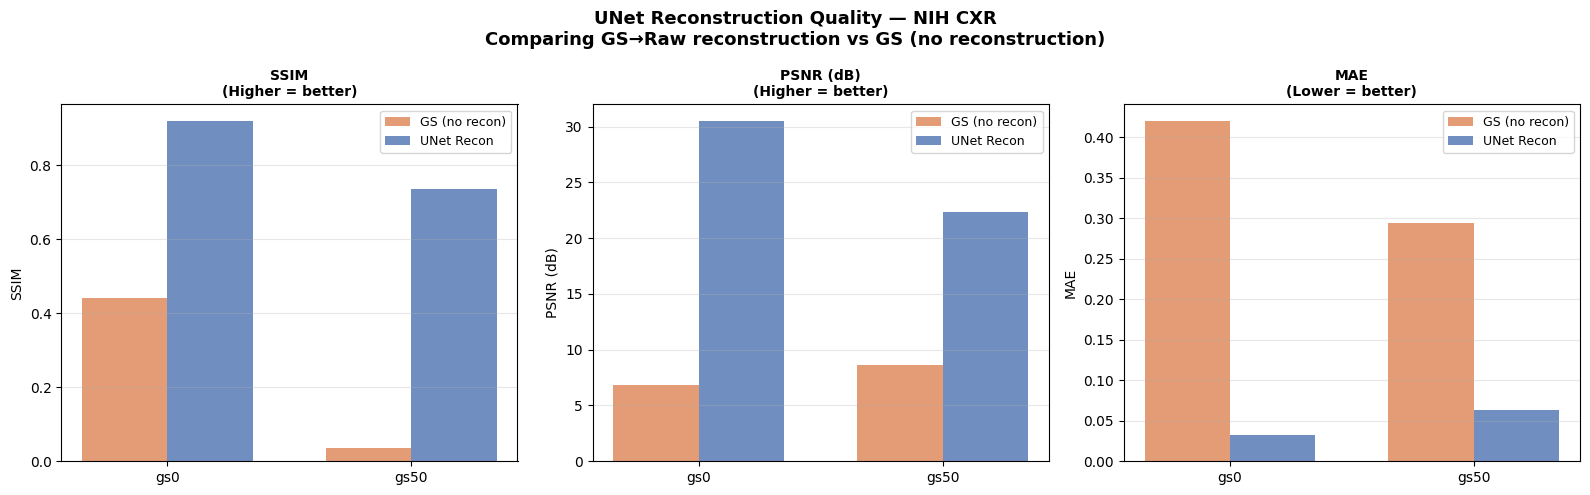

Saved → fig1_intensity_metrics.png


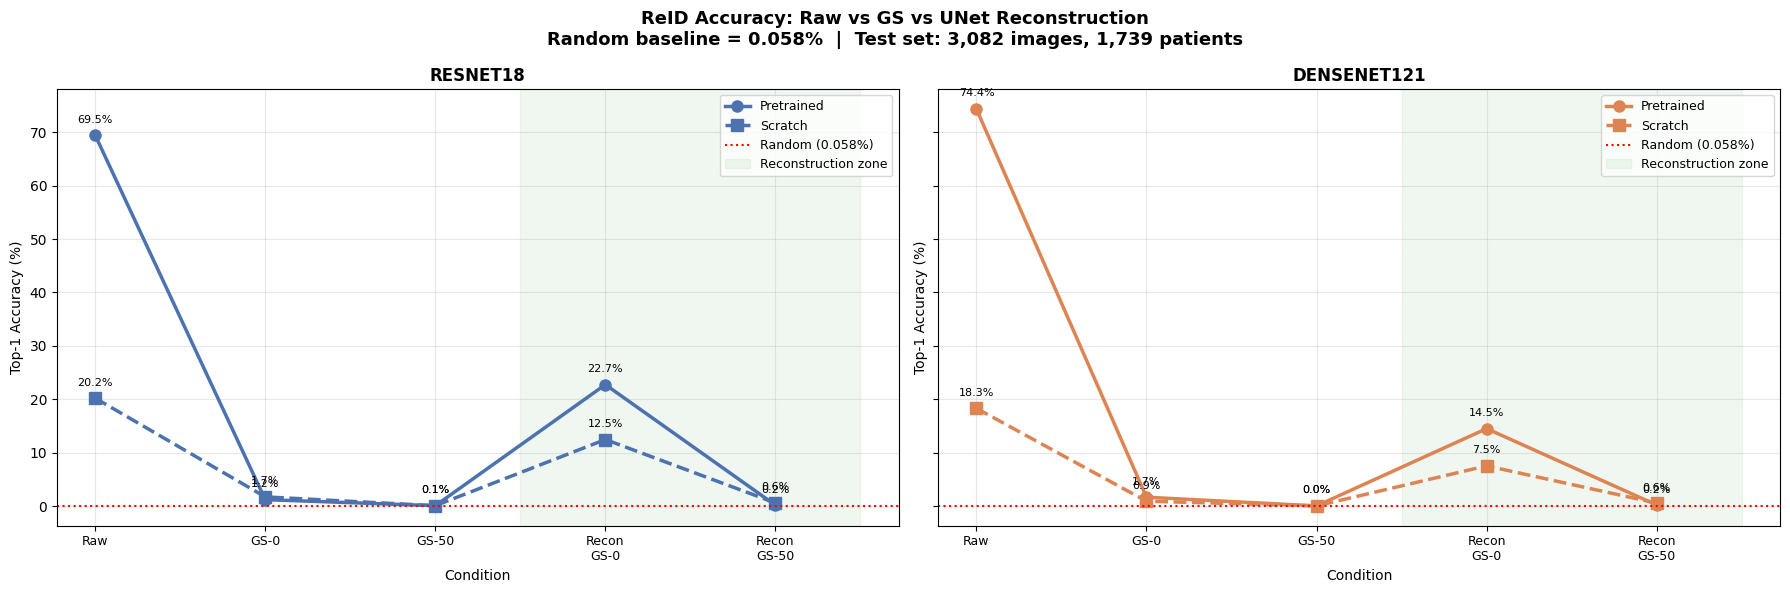

Saved → fig2_reid_accuracy.png


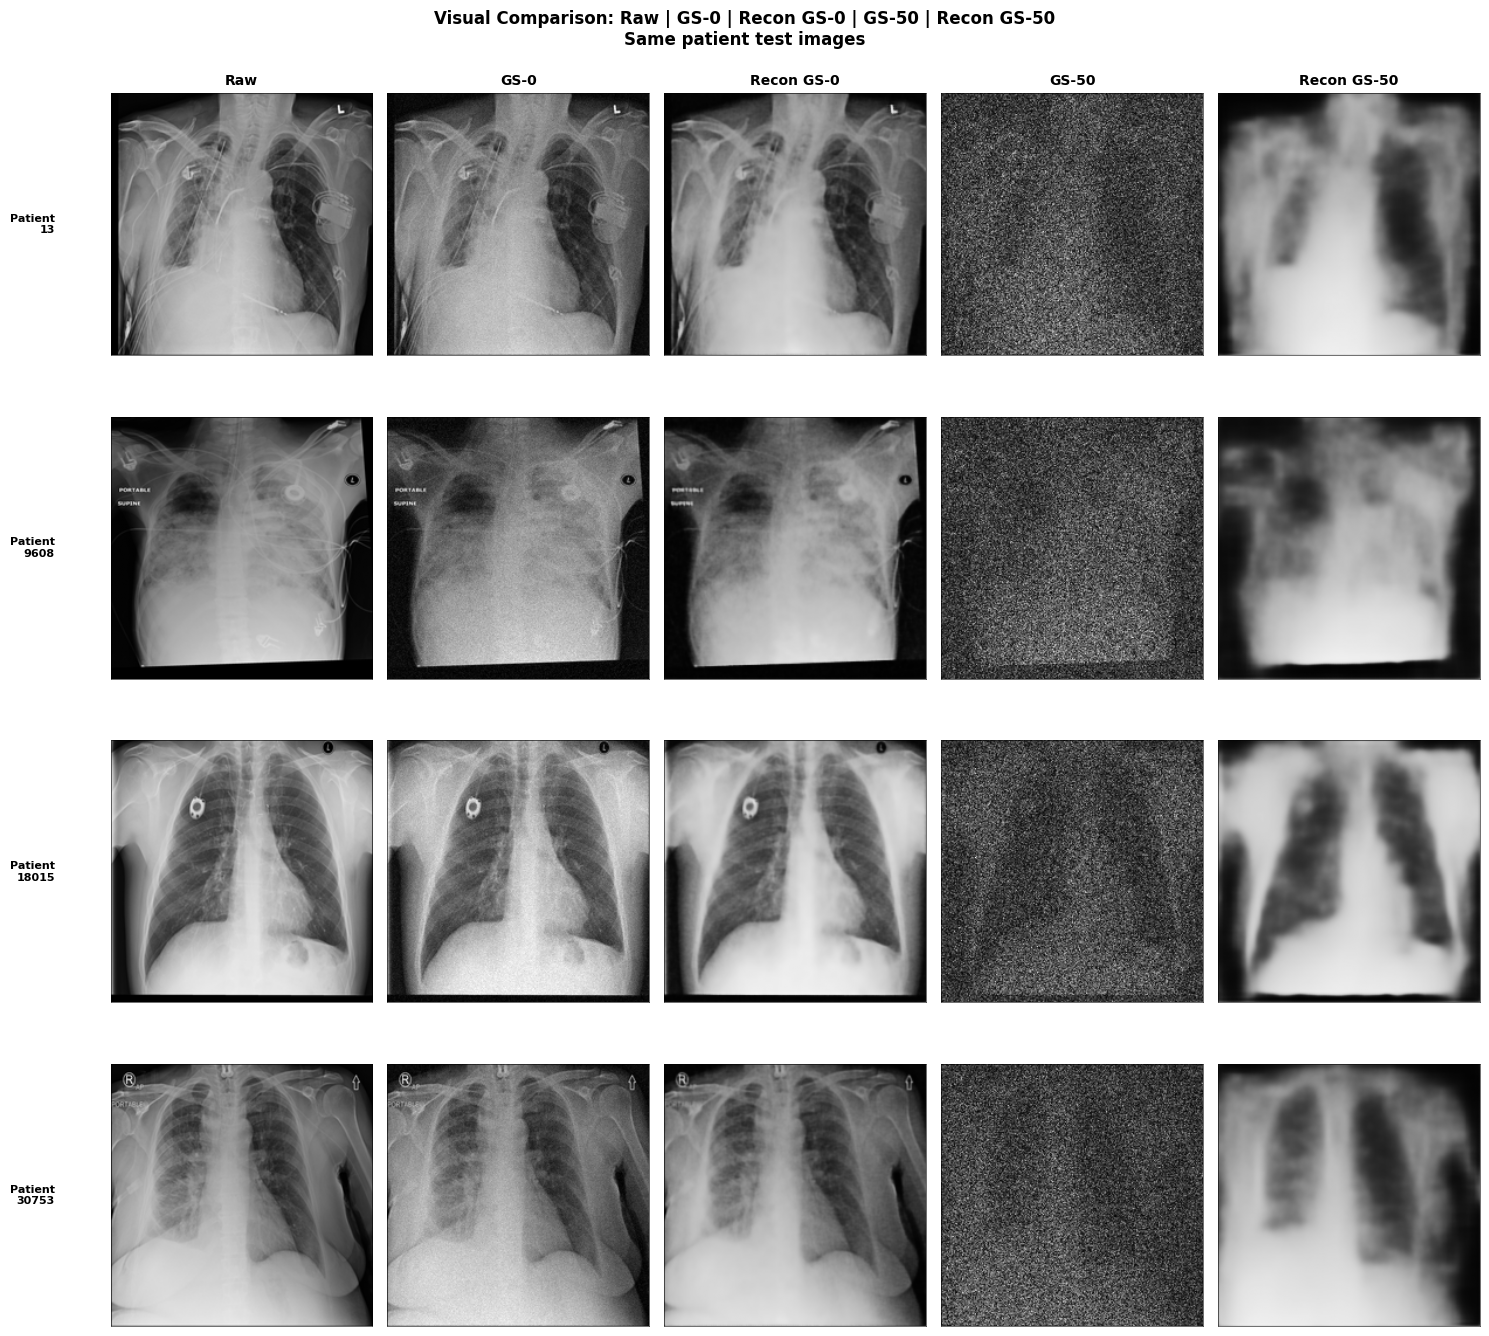

Saved → fig3_visual_examples.png

=== ALL FIGURES SAVED TO results/nih_cxr/unet/figures ===
  fig1_intensity_metrics.png
  fig2_reid_accuracy.png
  fig3_visual_examples.png


In [14]:
# =============================================================================
# VISUALISATION
# =============================================================================

ARCH_COLORS = {'resnet18': '#4C72B0', 'densenet121': '#DD8452'}
INIT_LINES  = {'Pretrained': ('-',  'o'), 'Scratch': ('--', 's')}

# ── Figure 1: Intensity metrics bar chart ────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle(
    'UNet Reconstruction Quality — NIH CXR\n'
    'Comparing GS→Raw reconstruction vs GS (no reconstruction)',
    fontsize=13, fontweight='bold'
)

metrics = [
    ('recon_ssim', 'gs_ssim', 'SSIM',     'Higher = better'),
    ('recon_psnr', 'gs_psnr', 'PSNR (dB)','Higher = better'),
    ('recon_mae',  'gs_mae',  'MAE',       'Lower = better'),
]

x_pos  = np.arange(len(df_intensity))
tags   = df_intensity['gs_level'].tolist()
width  = 0.35
colors = ['#4C72B0', '#DD8452']

for ax, (recon_col, gs_col, ylabel, note) in zip(axes, metrics):
    ax.bar(x_pos - width/2, df_intensity[gs_col],   width,
           label='GS (no recon)', color=colors[1], alpha=0.8)
    ax.bar(x_pos + width/2, df_intensity[recon_col], width,
           label='UNet Recon',    color=colors[0], alpha=0.8)
    ax.set_xticks(x_pos)
    ax.set_xticklabels(tags, fontsize=10)
    ax.set_ylabel(ylabel, fontsize=10)
    ax.set_title(f'{ylabel}\n({note})', fontsize=10, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(FIG_DIR / 'fig1_intensity_metrics.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Saved → fig1_intensity_metrics.png")


# ── Figure 2: ReID accuracy across conditions ─────────────────────────────────
cond_order  = ['raw', 'gs0', 'gs50', 'recon_gs0', 'recon_gs50']
cond_labels = ['Raw', 'GS-0', 'GS-50', 'Recon\nGS-0', 'Recon\nGS-50']

fig, axes = plt.subplots(1, 2, figsize=(18, 6), sharey=True)
fig.suptitle(
    'ReID Accuracy: Raw vs GS vs UNet Reconstruction\n'
    f'Random baseline = {RAND_BASELINE:.3f}%  |  '
    f'Test set: {len(test_labels):,} images, {NUM_CLASSES:,} patients',
    fontsize=13, fontweight='bold'
)

for ax_idx, arch in enumerate(ARCHITECTURES):
    ax      = axes[ax_idx]
    arch_df = df_reid[df_reid['arch'] == arch]

    for init in INITIALIZATIONS:
        init_df   = arch_df[arch_df['init'] == init]
        xs, ys    = [], []

        for x_idx, cond in enumerate(cond_order):
            row = init_df[init_df['condition'] == cond]
            if not row.empty:
                xs.append(x_idx)
                ys.append(float(row['top1_acc'].values[0]))

        if not xs:
            continue

        ls, mk = INIT_LINES[init]
        ax.plot(
            xs, ys,
            linestyle=ls, marker=mk,
            color=ARCH_COLORS[arch],
            linewidth=2.5, markersize=8,
            label=init
        )
        for xi, yi in zip(xs, ys):
            ax.annotate(
                f'{yi:.1f}%', (xi, yi),
                textcoords='offset points',
                xytext=(0, 9), ha='center', fontsize=8
            )

    ax.axhline(
        RAND_BASELINE, color='red', linestyle=':',
        linewidth=1.5, label=f'Random ({RAND_BASELINE:.3f}%)'
    )
    ax.axvspan(2.5, 4.5, alpha=0.06, color='green',
               label='Reconstruction zone')

    ax.set_title(arch.upper(), fontsize=12, fontweight='bold')
    ax.set_xticks(range(len(cond_order)))
    ax.set_xticklabels(cond_labels, fontsize=9)
    ax.set_xlabel('Condition')
    ax.set_ylabel('Top-1 Accuracy (%)')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(FIG_DIR / 'fig2_reid_accuracy.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Saved → fig2_reid_accuracy.png")


# ── Figure 3: Visual examples ─────────────────────────────────────────────────
N_SHOW     = 4
show_idx   = np.linspace(0, len(test_raw) - 1, N_SHOW, dtype=int)
col_titles = ['Raw', 'GS-0', 'Recon GS-0', 'GS-50', 'Recon GS-50']

fig, axes = plt.subplots(N_SHOW, 5, figsize=(15, 3.5 * N_SHOW))
fig.suptitle(
    'Visual Comparison: Raw | GS-0 | Recon GS-0 | GS-50 | Recon GS-50\n'
    'Same patient test images',
    fontsize=12, fontweight='bold'
)

for col_idx, title in enumerate(col_titles):
    axes[0][col_idx].set_title(title, fontsize=10, fontweight='bold')

for row_idx, img_idx in enumerate(show_idx):
    # GS images may be unbounded — display with auto vmin/vmax
    gs0_img  = gs_data[0.0]['test'][img_idx]
    gs50_img = gs_data[0.5]['test'][img_idx]

    images_to_show = [
        (test_raw[img_idx],   0, 1),
        (gs0_img,  gs0_img.min(),  gs0_img.max()),
        (eval_conditions.get('recon_gs0',
            {'dummy': np.zeros((len(test_raw), IMG_SIZE, IMG_SIZE))}
         )[img_idx] if 'recon_gs0' in eval_conditions
         else np.zeros((IMG_SIZE, IMG_SIZE)), 0, 1),
        (gs50_img, gs50_img.min(), gs50_img.max()),
        (eval_conditions.get('recon_gs50',
            {'dummy': np.zeros((len(test_raw), IMG_SIZE, IMG_SIZE))}
         )[img_idx] if 'recon_gs50' in eval_conditions
         else np.zeros((IMG_SIZE, IMG_SIZE)), 0, 1),
    ]

    for col_idx, (img, vmin, vmax) in enumerate(images_to_show):
        ax = axes[row_idx][col_idx]
        ax.imshow(img, cmap='gray', vmin=vmin, vmax=vmax,
                  interpolation='bilinear')
        ax.set_xticks([])
        ax.set_yticks([])
        for spine in ax.spines.values():
            spine.set_linewidth(0.4)

    axes[row_idx][0].set_ylabel(
        f'Patient\n{test_pids[img_idx]}',
        fontsize=8, fontweight='bold',
        rotation=0, ha='right', va='center', labelpad=40
    )

plt.tight_layout()
plt.savefig(FIG_DIR / 'fig3_visual_examples.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Saved → fig3_visual_examples.png")

print(f"\n=== ALL FIGURES SAVED TO {FIG_DIR} ===")
for f in sorted(FIG_DIR.iterdir()):
    print(f"  {f.name}")

In [15]:
# =============================================================================
# BONUS — ReID accuracy on reconstructed images using GS-trained models
# Tests whether GS-trained models can identify patients in reconstructions
# =============================================================================

def load_reid_model_gs(arch: str, init: str, gs_level: str) -> nn.Module:
    """Load ReID model trained on a specific GS condition."""
    fname = f'{arch}_{init}_{gs_level}_best.pth'
    path  = MODELS_DIR / arch / fname
    if not path.exists():
        raise FileNotFoundError(f"Not found: {path}")

    ckpt = torch.load(path, map_location=DEVICE, weights_only=False)
    sd   = ckpt.get('state_dict', ckpt)

    if arch == 'resnet18':
        has_seq = 'fc.1.weight' in sd
        model   = models.resnet18(weights=None)
        model.conv1 = nn.Conv2d(
            1, 64, kernel_size=7, stride=2, padding=3, bias=False
        )
        model.fc = nn.Sequential(
            nn.Dropout(0.0), nn.Linear(512, NUM_CLASSES)
        ) if has_seq else nn.Linear(512, NUM_CLASSES)
    else:
        has_seq = 'classifier.1.weight' in sd
        model   = models.densenet121(weights=None)
        model.features[0] = nn.Conv2d(
            1, 64, kernel_size=7, stride=2, padding=3, bias=False
        )
        model.classifier = nn.Sequential(
            nn.Dropout(0.0), nn.Linear(1024, NUM_CLASSES)
        ) if has_seq else nn.Linear(1024, NUM_CLASSES)

    model.load_state_dict(
        {k.replace('module.', ''): v for k, v in sd.items()}
    )
    return model.to(DEVICE).eval()


print("=" * 70)
print("BONUS — GS-trained models evaluating reconstructed images")
print("=" * 70)
print(f"Question: can a model trained on GS-X identify patients")
print(f"in UNet-reconstructed images?")
print()

# Conditions to test: GS model evaluates its own reconstruction
bonus_tests = [
    # (model_gs_level, eval_condition, description)
    ('gs0',  'recon_gs0',  'gs0-model  → recon_gs0  images'),
    ('gs0',  'raw',        'gs0-model  → raw         images'),
    ('gs50', 'recon_gs50', 'gs50-model → recon_gs50 images'),
    ('gs50', 'raw',        'gs50-model → raw         images'),
]

for model_gs, eval_cond, desc in bonus_tests:
    if eval_cond not in eval_conditions:
        print(f"  ✗ {eval_cond} not available — skip")
        continue

    imgs = eval_conditions[eval_cond]
    print(f"\n── {desc} ──────────────────────────")

    for arch in ARCHITECTURES:
        for init in INITIALIZATIONS:
            try:
                model       = load_reid_model_gs(arch, init, model_gs)
                top1, top5  = evaluate_reid(imgs, test_labels, model)
                del model
                torch.cuda.empty_cache()
                print(f"  {arch:<15} {init:<12} "
                      f"Top1={top1:.2f}%  Top5={top5:.2f}%")
            except FileNotFoundError as e:
                print(f"  ✗ {e}")

print(f"\nRandom baseline: {RAND_BASELINE:.3f}%")

BONUS — GS-trained models evaluating reconstructed images
Question: can a model trained on GS-X identify patients
in UNet-reconstructed images?


── gs0-model  → recon_gs0  images ──────────────────────────
  resnet18        Pretrained   Top1=12.91%  Top5=29.23%
  resnet18        Scratch      Top1=7.37%  Top5=18.40%
  densenet121     Pretrained   Top1=13.21%  Top5=28.52%
  densenet121     Scratch      Top1=3.31%  Top5=10.67%

── gs0-model  → raw         images ──────────────────────────
  resnet18        Pretrained   Top1=27.06%  Top5=45.04%
  resnet18        Scratch      Top1=10.19%  Top5=23.78%
  densenet121     Pretrained   Top1=21.45%  Top5=38.45%
  densenet121     Scratch      Top1=4.93%  Top5=13.72%

── gs50-model → recon_gs50 images ──────────────────────────
  resnet18        Pretrained   Top1=0.06%  Top5=0.26%
  resnet18        Scratch      Top1=0.06%  Top5=0.39%
  densenet121     Pretrained   Top1=0.06%  Top5=0.36%
  densenet121     Scratch      Top1=0.06%  Top5=0.36%

── gs5